### Cell 1: Setup & Environment
Перед запуском надо обновить путь к папке с датой в Cell 2


In [2]:
!pip -q install setfit datasets sentence-transformers pandas seaborn matplotlib scikit-learn pyarrow transformers accelerate

import gc
import logging
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from google.colab import drive

# Keep HF Hub auth warnings informational-only for public model downloads.
os.environ.setdefault('HF_HUB_DISABLE_IMPLICIT_TOKEN', '1')
warnings.filterwarnings(
    'ignore',
    message='.*HF_TOKEN.*does not exist.*',
)
logging.getLogger('huggingface_hub.utils._http').setLevel(logging.ERROR)

drive.mount('/content/drive')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Mounted at /content/drive


### Cell 2: Local Data Loading 77 Classes
Load train/test parquet plus seed_train_77.csv and augmented_train_77.csv from /content/drive/MyDrive/Colab Notebooks/SBER/data(change if needed), then build train_seed and train_augmented = concat(seed_train, augmented_train).

In [3]:
data_dir = Path('/content/drive/MyDrive/Colab Notebooks/SBER/data')
if not data_dir.exists():
    raise FileNotFoundError(
        'Expected data directory at /content/drive/MyDrive/Colab Notebooks/SBER/data with train.parquet, test.parquet, seed_train_77.csv, and augmented_train_77.csv.'
    )

train_parquet_path = data_dir / 'train.parquet'
test_parquet_path = data_dir / 'test.parquet'
seed_csv_path = data_dir / 'seed_train_77.csv'
augmented_csv_path = data_dir / 'augmented_train_77.csv'

train_df = pd.read_parquet(train_parquet_path)
test_df = pd.read_parquet(test_parquet_path)
seed_train = pd.read_csv(seed_csv_path)
augmented_train_only = pd.read_csv(augmented_csv_path)

print('data_dir:', data_dir)
print('train.parquet:', train_df.shape)
print('test.parquet:', test_df.shape)
print('seed_train_77.csv:', seed_train.shape)
print('augmented_train_77.csv (synthetic only):', augmented_train_only.shape)

text_col_candidates = ['text', 'sentence', 'query', 'utterance', 'question']
label_col_candidates = ['label', 'intent', 'category', 'target']

train_text_col = next((c for c in text_col_candidates if c in train_df.columns), None)
if train_text_col is None:
    object_cols = [c for c in train_df.columns if train_df[c].dtype == 'object']
    if not object_cols:
        raise ValueError('No text column found in train.parquet')
    train_text_col = object_cols[0]

test_text_col = next((c for c in text_col_candidates if c in test_df.columns), None)
if test_text_col is None:
    object_cols_test = [c for c in test_df.columns if test_df[c].dtype == 'object']
    if not object_cols_test:
        raise ValueError('No text column found in test.parquet')
    test_text_col = object_cols_test[0]

test_label_col = next((c for c in label_col_candidates if c in test_df.columns), None)
if test_label_col is None:
    non_text_cols = [c for c in test_df.columns if c != test_text_col]
    if not non_text_cols:
        raise ValueError('No label column found in test.parquet')
    test_label_col = non_text_cols[0]

for df_name, df_obj in [('seed_train_77.csv', seed_train), ('augmented_train_77.csv', augmented_train_only)]:
    if 'text' not in df_obj.columns or 'label' not in df_obj.columns:
        raise ValueError(f'{df_name} must contain text,label columns')

seed_train = seed_train[['text', 'label']].dropna().copy()
augmented_train_only = augmented_train_only[['text', 'label']].dropna().copy()

seed_train['text'] = seed_train['text'].astype(str)
augmented_train_only['text'] = augmented_train_only['text'].astype(str)
seed_train['label'] = pd.to_numeric(seed_train['label'], errors='raise').astype(int)
augmented_train_only['label'] = pd.to_numeric(augmented_train_only['label'], errors='raise').astype(int)

# Baseline dataset (human seeds only).
train_seed = seed_train.reset_index(drop=True)
# SOTA/failure pipelines dataset: seeds + synthetic augmentations.
train_augmented = pd.concat([seed_train, augmented_train_only], ignore_index=True)

raw_texts = train_df[train_text_col].dropna().astype(str).tolist()

print('raw_texts for adaptation:', len(raw_texts))
print('train_seed shape:', train_seed.shape)
print('train_augmented shape:', train_augmented.shape)
print('seed classes:', train_seed['label'].nunique())
print('augmented-only classes:', augmented_train_only['label'].nunique())
print('combined classes:', train_augmented['label'].nunique())
train_seed.head()

data_dir: /content/drive/MyDrive/Colab Notebooks/SBER/data
train.parquet: (10003, 2)
test.parquet: (3080, 2)
seed_train_77.csv: (385, 2)
augmented_train_77.csv (synthetic only): (1155, 2)
raw_texts for adaptation: 10003
train_seed shape: (385, 2)
train_augmented shape: (1540, 2)
seed classes: 77
augmented-only classes: 77
combined classes: 77


,text,label
0,I tried activating my plug-in and it didn't pi...,0
1,I tired but an unable to activate my card.,0
2,I want to start using my card.,0
3,Please help me with my card. It won't activate.,0
4,How do I verify my new card?,0


### Cell 3: Dual Domain Adaptation (MLM  vs SimCSE Solution)
MLM - Masked Language Modeling
SimCSE - Simple Contrastive Learning of Sentence Embeddings
Adaptation A: MLM on bge-m3.
Adaptation B: Unsupervised SimCSE with MultipleNegativesRankingLoss (epochs=3, batch_size=32).

In [4]:
import inspect
import warnings
from datasets import Dataset as HFDataset
from sentence_transformers import InputExample, SentenceTransformer, losses
from torch.utils.data import DataLoader
from transformers import (
    AutoModelForMaskedLM,
    AutoTokenizer,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
)

warnings.filterwarnings(
    "ignore",
    message=".*HF_TOKEN.*does not exist.*",
)

base_model_id = 'BAAI/bge-m3'
bge_m3_adapted_mlm = '/content/bge-m3-adapted-mlm'

# -------------------- Adaptation A: MLM (Failure baseline) --------------------
mlm_dataset = HFDataset.from_dict({'text': raw_texts})
tokenizer = AutoTokenizer.from_pretrained(base_model_id, trust_remote_code=True)

if tokenizer.mask_token is None:
    raise ValueError('Tokenizer has no mask_token, MLM cannot be run.')

def tokenize_batch(batch):
    return tokenizer(batch['text'], truncation=True, max_length=256, padding='max_length')

tokenized_mlm = mlm_dataset.map(tokenize_batch, batched=True, remove_columns=['text'])
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=True, mlm_probability=0.15)

mlm_model = AutoModelForMaskedLM.from_pretrained(
    base_model_id,
    trust_remote_code=True,
    ignore_mismatched_sizes=True,
 )

ta_params = inspect.signature(TrainingArguments.__init__).parameters
ta_kwargs = {
    'output_dir': '/content/bge_m3_mlm_tmp',
    'num_train_epochs': 1,
    'per_device_train_batch_size': 16,
    'learning_rate': 5e-5,
    'weight_decay': 0.01,
    'logging_steps': 50,
    'report_to': 'none',
}

if 'overwrite_output_dir' in ta_params:
    ta_kwargs['overwrite_output_dir'] = True

if 'save_strategy' in ta_params:
    ta_kwargs['save_strategy'] = 'no'
elif 'save_steps' in ta_params:
    ta_kwargs['save_steps'] = 10**9

if 'fp16' in ta_params:
    ta_kwargs['fp16'] = torch.cuda.is_available()
elif 'bf16' in ta_params:
    ta_kwargs['bf16'] = bool(torch.cuda.is_available() and torch.cuda.is_bf16_supported())

mlm_args = TrainingArguments(**ta_kwargs)

mlm_trainer = Trainer(
    model=mlm_model,
    args=mlm_args,
    train_dataset=tokenized_mlm,
    data_collator=data_collator,
)

mlm_trainer.train()
mlm_model.save_pretrained(bge_m3_adapted_mlm)
tokenizer.save_pretrained(bge_m3_adapted_mlm)
print(f'MLM-adapted checkpoint saved to: {bge_m3_adapted_mlm}')

# Build in-memory sentence embedding model from MLM-adapted encoder.
mlm_encoder = AutoModelForMaskedLM.from_pretrained(
    bge_m3_adapted_mlm,
    trust_remote_code=True,
    ignore_mismatched_sizes=True,
 )
model_mlm = SentenceTransformer(base_model_id, trust_remote_code=True)
missing_keys, unexpected_keys = model_mlm[0].auto_model.load_state_dict(
    mlm_encoder.base_model.state_dict(),
    strict=False,
 )
print(f'MLM encoder transfer: missing={len(missing_keys)}, unexpected={len(unexpected_keys)}')

del mlm_trainer, mlm_model, mlm_encoder, tokenized_mlm, mlm_dataset, data_collator
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# -------------------- Adaptation B: Unsupervised SimCSE (Solution) --------------------
simcse_examples = [InputExample(texts=[t, t]) for t in raw_texts]
simcse_loader = DataLoader(simcse_examples, batch_size=32, shuffle=True, drop_last=True)

model_simcse = SentenceTransformer(base_model_id, trust_remote_code=True)
simcse_loss = losses.MultipleNegativesRankingLoss(model_simcse)
warmup_steps = int(len(simcse_loader) * 0.1)

model_simcse.fit(
    train_objectives=[(simcse_loader, simcse_loss)],
    epochs=3,
    warmup_steps=warmup_steps,
    show_progress_bar=True,
)
print('SimCSE adaptation finished (in-memory model_simcse).')

model_registry = {
    'bge-m3-base': base_model_id,
    'model_mlm': model_mlm,
    'model_simcse': model_simcse,
}

del simcse_examples, simcse_loader, simcse_loss
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

...

MLM encoder transfer: missing=2, unexpected=0


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
500,0.001916


SimCSE adaptation finished (in-memory model_simcse).


### Cell 4: SetFit Core Logic
SetFit training function (contrastive learning + Logistic Regression) and evaluation on the full test.parquet.

In [5]:
from datetime import datetime
from pathlib import Path
import inspect
import socket

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sentence_transformers import SentenceTransformer
import transformers.training_args as hf_training_args

# Compatibility patch: newer transformers may not expose default_logdir,
# while some setfit versions import it directly.
if not hasattr(hf_training_args, 'default_logdir'):
    def _default_logdir() -> str:
        current_time = datetime.now().strftime('%b%d_%H-%M-%S')
        return str(Path('runs') / f'{current_time}_{socket.gethostname()}')
    hf_training_args.default_logdir = _default_logdir

from setfit import SetFitModel

def _make_default_head():
    return LogisticRegression(max_iter=2000, random_state=42)

def load_setfit_model(model_ref):
    if isinstance(model_ref, SetFitModel):
        model = model_ref
    elif isinstance(model_ref, SentenceTransformer):
        model = SetFitModel(model_body=model_ref, model_head=_make_default_head())
    elif isinstance(model_ref, str):
        try:
            model = SetFitModel.from_pretrained(model_ref, trust_remote_code=True)
        except Exception as exc:
            # Fallback for plain sentence-transformers repos without config_setfit.json.
            print(f'[SetFit fallback] Using SentenceTransformer body for: {model_ref}')
            print(f'[SetFit fallback] Reason: {type(exc).__name__}: {exc}')
            body = SentenceTransformer(model_ref, trust_remote_code=True)
            model = SetFitModel(model_body=body, model_head=_make_default_head())
    else:
        raise TypeError(f'Unsupported model_ref type: {type(model_ref)}')

    # Ensure sklearn head exists for non-end-to-end SetFit training.
    if getattr(model, 'model_head', None) is None:
        model.model_head = _make_default_head()
    return model

def fit_setfit_model(model, x_train, y_train):
    fit_params = inspect.signature(model.fit).parameters

    optional_args = {}
    for arg_name, arg_value in {
        'num_iterations': 20,
        'num_epochs': 1,
        'batch_size': 16,
    }.items():
        if arg_name in fit_params:
            optional_args[arg_name] = arg_value

    try:
        if 'x_train' in fit_params and 'y_train' in fit_params:
            model.fit(x_train=x_train, y_train=y_train, **optional_args)
        else:
            model.fit(x_train, y_train, **optional_args)
    except TypeError:
        # Minimal fallback for strict/legacy signatures.
        model.fit(x_train, y_train)

def train_setfit_and_evaluate(model_ref, train_data: pd.DataFrame, test_data: pd.DataFrame, run_name: str):
    train_local = train_data[['text', 'label']].dropna().copy()
    test_local = test_data[[test_text_col, test_label_col]].dropna().copy()

    train_local['text'] = train_local['text'].astype(str)
    test_local[test_text_col] = test_local[test_text_col].astype(str)

    # Keep labels as integers for consistent training/evaluation.
    train_local['label'] = pd.to_numeric(train_local['label'], errors='raise').astype(int)
    test_local[test_label_col] = pd.to_numeric(test_local[test_label_col], errors='coerce')
    test_local = test_local.dropna(subset=[test_label_col]).copy()
    test_local[test_label_col] = test_local[test_label_col].astype(int)

    # Evaluate on all classes present in test.parquet (no hardcoded filtering).
    eval_labels = sorted(test_local[test_label_col].unique().tolist())

    model = load_setfit_model(model_ref)

    fit_setfit_model(
        model=model,
        x_train=train_local['text'].tolist(),
        y_train=train_local['label'].tolist(),
    )

    y_true = test_local[test_label_col].tolist()
    y_pred = model.predict(test_local[test_text_col].tolist())
    if hasattr(y_pred, 'tolist'):
        y_pred = y_pred.tolist()
    y_pred = [int(y) for y in y_pred]

    metrics = {
        'experiment': run_name,
        'f1_macro': float(f1_score(y_true, y_pred, average='macro')),
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'eval_size': int(len(test_local)),
        'label_set': str(eval_labels),
    }
    eval_outputs = {
        'y_true': y_true,
        'y_pred': y_pred,
        'labels': eval_labels,
    }
    return metrics, model, eval_outputs

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Cell 5: 4-Stage Ablation Execution (77 Classes)
Baseline uses train_seed; all other pipelines use train_augmented = concat(seed_train, augmented_train).

In [6]:
results = []
run_outputs = {}

experiments = [
    ('Baseline: bge-m3 + train_seed', model_registry['bge-m3-base'], train_seed),
    ('Augmented: bge-m3 + train_augmented', model_registry['bge-m3-base'], train_augmented),
    ('Failed Adaptation: model_mlm + train_augmented', model_registry['model_mlm'], train_augmented),
    ('SOTA Pipeline: model_simcse + train_augmented', model_registry['model_simcse'], train_augmented),
]

for exp_name, model_ref, train_data in experiments:
    print(f'\n==== Running: {exp_name} ====')

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

    metrics, fitted_model, eval_outputs = train_setfit_and_evaluate(
        model_ref=model_ref,
        train_data=train_data,
        test_data=test_df,
        run_name=exp_name,
    )
    results.append(metrics)
    run_outputs[exp_name] = eval_outputs
    print(metrics)

    del fitted_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

results_df = pd.DataFrame(results)
results_path = data_dir / 'ablation_results.csv'
results_df.to_csv(results_path, index=False)

display(results_df)
print(f'Results saved to: {results_path}')


==== Running: Baseline: bge-m3 + train_seed ====


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[SetFit fallback] Using SentenceTransformer body for: BAAI/bge-m3
[SetFit fallback] Reason: RemoteEntryNotFoundError: 404 Client Error. (Request ID: Root=1-69d71fc7-4a03a6f641c78c6743771203;62577da9-ee49-4a7e-b92a-a83267eae30d)

Entry Not Found for url: https://huggingface.co/BAAI/bge-m3/resolve/main/config_setfit.json.


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datet

{'experiment': 'SOTA Pipeline: model_simcse + train_augmented', 'f1_macro': 0.694062535617673, 'accuracy': 0.6993506493506494, 'eval_size': 3080, 'label_set': '[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76]'}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,experiment,f1_macro,accuracy,eval_size,label_set
0,Baseline: bge-m3 + train_seed,0.763672,0.777273,3080,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
1,Augmented: bge-m3 + train_augmented,0.825950,0.834416,3080,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
2,Failed Adaptation: model_mlm + train_augmented,0.623726,0.641558,3080,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
3,SOTA Pipeline: model_simcse + train_augmented,0.694063,0.699351,3080,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."


Results saved to: /content/drive/MyDrive/Colab Notebooks/SBER/data/ablation_results.csv


### Cell 6: Deep Analytics & Visualization (77 Classes)
F1 chart for ablation experiments plus error analysis of the 10 lowest per-class F1 scores in the SOTA pipeline (confusion matrix removed).

/tmp/ipykernel_19352/2343110104.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=results_df, x='experiment', y='f1_macro', palette='Set2')
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


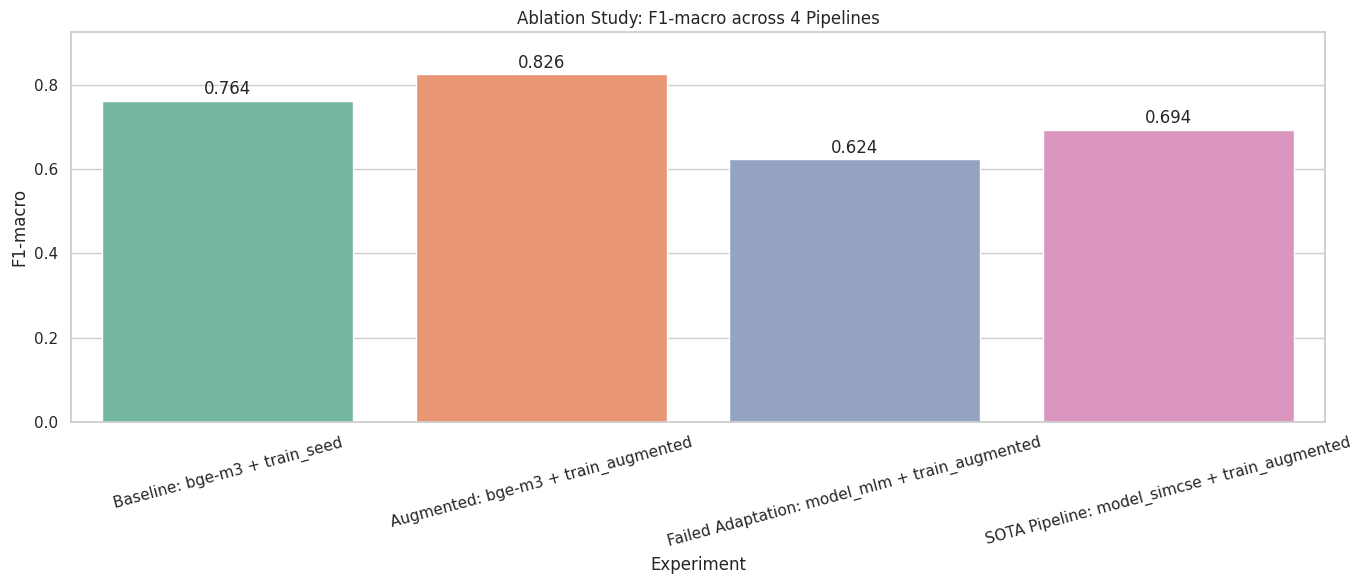

/tmp/ipykernel_19352/2343110104.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(data=bottom10, x='f1_score', y='label_id', palette='Reds_r')
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


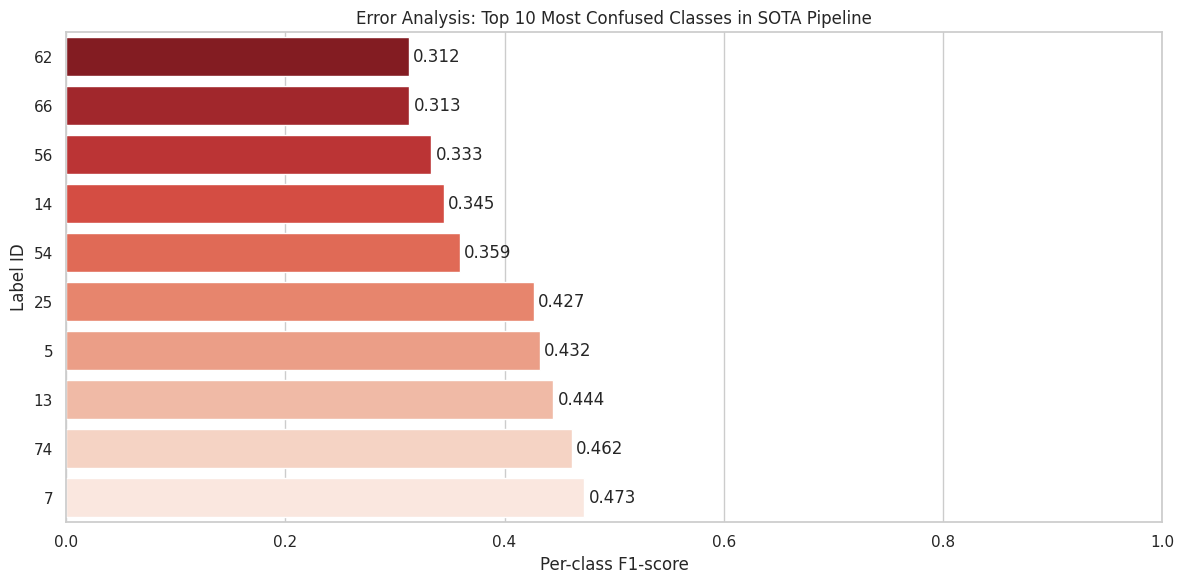

,label,f1_macro
62,62,0.312500
66,66,0.313253
56,56,0.333333
14,14,0.344828
54,54,0.358974
25,25,0.426667
5,5,0.432432
13,13,0.444444
74,74,0.461538
7,7,0.472727


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report

sns.set_theme(style='whitegrid')

# 1) F1-macro comparison across 4 ablation stages.
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=results_df, x='experiment', y='f1_macro', palette='Set2')
ax.set_title('Ablation Study: F1-macro across 4 Pipelines')
ax.set_xlabel('Experiment')
ax.set_ylabel('F1-macro')
ax.set_ylim(0, min(1.0, results_df['f1_macro'].max() + 0.1))
ax.tick_params(axis='x', rotation=15)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2)
plt.tight_layout()
plt.show()

# 2) Error analysis for the final SOTA pipeline: bottom-10 per-class F1 scores.
sota_name = 'SOTA Pipeline: model_simcse + train_augmented'
if sota_name not in run_outputs:
    raise ValueError('SOTA outputs are missing. Run Cell 5 before Cell 6.')

sota_true = run_outputs[sota_name]['y_true']
sota_pred = run_outputs[sota_name]['y_pred']
sota_labels = run_outputs[sota_name]['labels']

report_dict = classification_report(
    sota_true,
    sota_pred,
    labels=sota_labels,
    digits=4,
    zero_division=0,
    output_dict=True,
 )

label_keys = {str(lbl) for lbl in sota_labels}
per_class_rows = []
for label_key, metrics in report_dict.items():
    if label_key in label_keys and isinstance(metrics, dict):
        per_class_rows.append(
            {
                'label_id': int(label_key),
                'f1_score': float(metrics.get('f1-score', 0.0)),
            }
        )

if not per_class_rows:
    raise ValueError('Could not extract per-class F1-scores from SOTA classification report.')

per_class_f1_df = pd.DataFrame(per_class_rows).sort_values('f1_score', ascending=True)
bottom10 = per_class_f1_df.head(10).copy()
bottom10['label_id'] = bottom10['label_id'].astype(str)

plt.figure(figsize=(12, 6))
ax2 = sns.barplot(data=bottom10, x='f1_score', y='label_id', palette='Reds_r')
ax2.set_title('Error Analysis: Top 10 Most Confused Classes in SOTA Pipeline')
ax2.set_xlabel('Per-class F1-score')
ax2.set_ylabel('Label ID')
ax2.set_xlim(0, 1.0)
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.3f', padding=3)
plt.tight_layout()
plt.show()

display(bottom10.rename(columns={'label_id': 'label', 'f1_score': 'f1_macro'}))